# 0. Setup

In [36]:
# @title 0.0 Check computing device (CPU vs GPU)
import torch

# Print PyTorch version (useful for reproducibility)
print("PyTorch version:", torch.__version__)

# Check if CUDA (GPU) is available
cuda_available = torch.cuda.is_available()
print("CUDA available:", cuda_available)

# If GPU is available, print the GPU name
if cuda_available:
    print("GPU name:", torch.cuda.get_device_name(0))

# Set device: use GPU if available, otherwise fallback to CPU
device = torch.device("cuda" if cuda_available else "cpu")
print("Using device:", device)

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU name: Tesla T4
Using device: cuda


In [37]:
# @title 0.1 Imports

# Image dataset (cells3d) and evaluation metric
from skimage import data
from skimage.metrics import structural_similarity as ssim  # SSIM for image quality evaluation

# Basic tools
import numpy as np
import matplotlib.pyplot as plt
import cv2

# PyTorch modules
import torch.nn as nn
import torch.nn.functional as F

# Dataset utilities for training pipeline
from torch.utils.data import Dataset, DataLoader, random_split

Stack shape (Z, H, W): (60, 256, 256)
Value range: 0.0 to 1.0


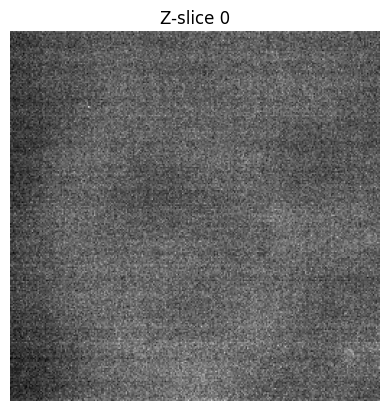

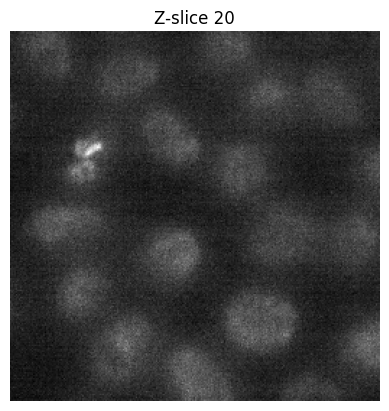

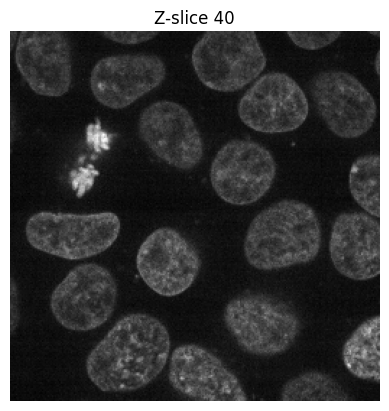

In [38]:
# @title 0.3 Load microscopy z-stack data

# Load 3D microscopy dataset
cells = data.cells3d()

# Select nuclei channel
stack = cells[:, 1].astype(np.float32)   # shape: (Z, H, W)

# Normalize to [0, 1] for stable training
stack = stack / stack.max()

print("Stack shape (Z, H, W):", stack.shape)
print("Value range:", stack.min(), "to", stack.max())

# Visualize slices along the z-axis
for i in range(0, len(stack), 20):
    plt.imshow(stack[i], cmap='gray')
    plt.title(f"Z-slice {i}")
    plt.axis('off')
    plt.show()

# 1. Baseline

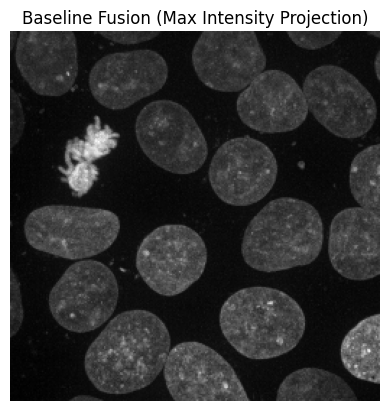

In [39]:
# @title 1.1 Generate baseline (ground truth fusion)

# Apply Max Intensity Projection (MIP) along the z-axis
# This serves as the "ideal" fused image without any physical degradation
baseline = np.max(stack, axis=0)

# Visualize
plt.imshow(baseline, cmap='gray')
plt.title("Baseline Fusion (Max Intensity Projection)")
plt.axis('off')
plt.show()

# 2. Physical Degradation Modeling

In [40]:
# @title 2.1 Simulate cumulative XY drift

def add_xy_drift(stack, max_shift=6, seed=42):
    """
    Simulate cumulative XY stage drift across a z-stack.

    Parameters
    ----------
    stack : np.ndarray
        Input image stack with shape (Z, H, W).
    max_shift : int, optional
        Maximum allowed cumulative shift in pixels along each axis.
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    drifted : np.ndarray
        Drifted image stack with the same shape as the input.
    """
    rng = np.random.default_rng(seed)
    Z, H, W = stack.shape
    drifted = np.zeros_like(stack)

    # Initialize cumulative drift in x and y
    cum_dx, cum_dy = 0, 0

    for i in range(Z):
        # Random step at each slice to mimic gradual stage drift
        step_dx = rng.integers(-2, 3)
        step_dy = rng.integers(-2, 3)

        # Accumulate drift over depth, while constraining the total shift
        cum_dx = np.clip(cum_dx + step_dx, -max_shift, max_shift)
        cum_dy = np.clip(cum_dy + step_dy, -max_shift, max_shift)

        # Construct affine translation matrix
        M = np.float32([
            [1, 0, cum_dx],
            [0, 1, cum_dy]
        ])

        # Apply translation to the current slice
        drifted[i] = cv2.warpAffine(
            stack[i],
            M,
            (W, H),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT
        )

    return drifted

In [41]:
# @title 2.2 Simulate Z drift (defocus blur)

def add_z_drift(stack, max_sigma=2.0):
    """
    Simulate depth-dependent defocus along the z-axis.

    Parameters
    ----------
    stack : np.ndarray
        Input image stack with shape (Z, H, W).
    max_sigma : float, optional
        Maximum Gaussian blur (at the farthest distance from focal plane).

    Returns
    -------
    drifted : np.ndarray
        Blurred stack with depth-dependent defocus applied.
    """
    Z, H, W = stack.shape
    drifted = np.zeros_like(stack)

    for i in range(Z):
        # Compute normalized distance from focal plane (center slice)
        delta = (i - Z // 2) / (Z // 2)

        # Blur strength increases with distance from focal plane
        sigma = abs(delta) * max_sigma

        img = stack[i].astype(np.float32)

        # Apply Gaussian blur only if sigma is significant
        if sigma > 0.05:
            img = cv2.GaussianBlur(img, (5, 5), sigma)

        drifted[i] = img.astype(stack.dtype)

    return drifted

In [42]:
# @title 2.3 Combined drift (XY + Z)
def add_xy_z_drift(stack, max_shift=6, max_sigma=2.0, seed=42):
    """
    Apply combined imaging degradation:
    1) depth-dependent defocus blur
    2) cumulative XY stage drift
    """
    blurred = add_z_drift(stack, max_sigma=max_sigma)
    drifted = add_xy_drift(blurred, max_shift=max_shift, seed=seed)
    return drifted


# 3. Results of Physical Degradation

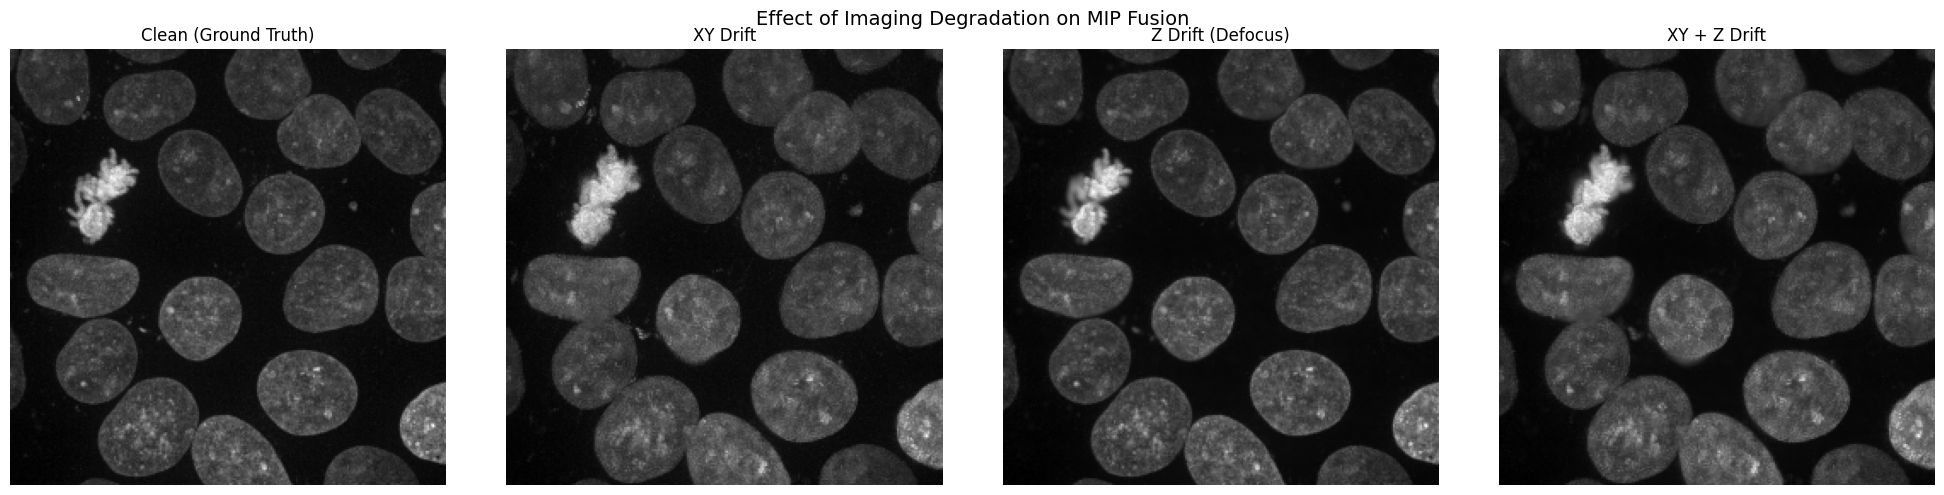

In [43]:
# @title 3.1 Visualize the result
#Fusion (Max Intensity Projection)

def mip_fusion(stack):
    """Apply Max Intensity Projection along z-axis."""
    return np.max(stack, axis=0)

#Generate degraded datasets
clean_stack = stack.copy()

# Apply individual and combined degradations
xy_stack = add_xy_drift(clean_stack)
z_stack = add_z_drift(clean_stack)
xy_z_stack = add_xy_z_drift(clean_stack)

#Generate fusion results
clean_fusion = mip_fusion(clean_stack)
xy_fusion = mip_fusion(xy_stack)
z_fusion = mip_fusion(z_stack)
xy_z_fusion = mip_fusion(xy_z_stack)

#Visualization
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

titles = ["Clean (Ground Truth)", "XY Drift", "Z Drift (Defocus)", "XY + Z Drift"]
images = [clean_fusion, xy_fusion, z_fusion, xy_z_fusion]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.suptitle("Effect of Imaging Degradation on MIP Fusion", fontsize=14)
plt.tight_layout()
plt.show()

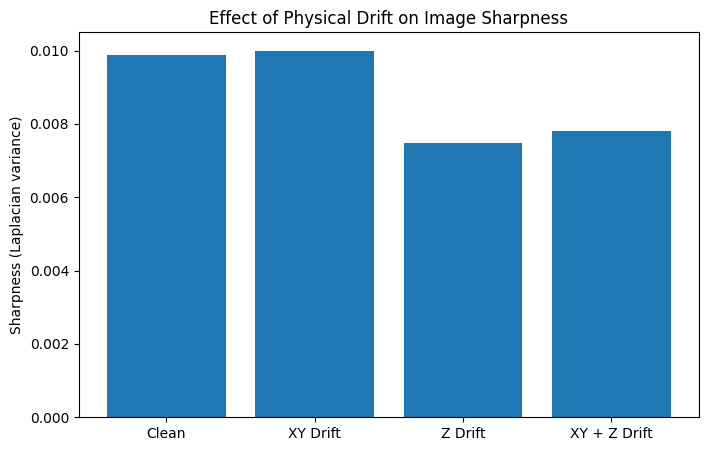

Sharpness:
Clean: 0.01
XY Drift: 0.01
Z Drift: 0.01
XY + Z Drift: 0.01

SSIM (vs Clean):
Clean: 1.0000
XY Drift: 0.5646
Z Drift: 0.9462
XY + Z Drift: 0.5755


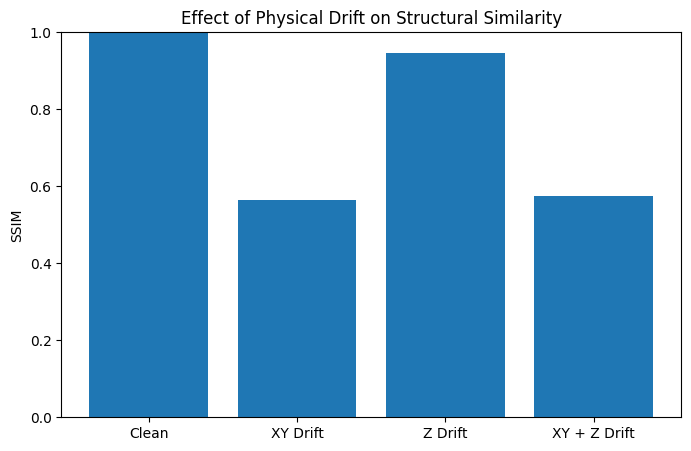

In [44]:
# @title 3.2 Quantitative analysis

# --- Sharpness metric (Laplacian variance) ---
def sharpness(img):
    """
    Estimate image sharpness using Laplacian variance.
    Higher value = more high-frequency content (sharper image).
    """
    return cv2.Laplacian(img.astype(np.float32), cv2.CV_32F).var()


sharpness_values = [
    sharpness(clean_fusion),
    sharpness(xy_fusion),
    sharpness(z_fusion),
    sharpness(xy_z_fusion)
]

labels = ["Clean", "XY Drift", "Z Drift", "XY + Z Drift"]

# Plot sharpness
plt.figure(figsize=(8, 5))
plt.bar(labels, sharpness_values)
plt.ylabel("Sharpness (Laplacian variance)")
plt.title("Effect of Physical Drift on Image Sharpness")
plt.show()

# Print values
print("Sharpness:")
for l, v in zip(labels, sharpness_values):
    print(f"{l}: {v:.2f}")


# --- SSIM metric ---
def compute_ssim(ref, img):
    """
    Compute Structural Similarity Index (SSIM) with respect to reference.
    """
    return ssim(ref, img, data_range=1.0)


ssim_values = [
    compute_ssim(clean_fusion, clean_fusion),
    compute_ssim(clean_fusion, xy_fusion),
    compute_ssim(clean_fusion, z_fusion),
    compute_ssim(clean_fusion, xy_z_fusion)
]

# Print SSIM
print("\nSSIM (vs Clean):")
for l, v in zip(labels, ssim_values):
    print(f"{l}: {v:.4f}")


# Plot SSIM
plt.figure(figsize=(8, 5))
plt.bar(labels, ssim_values)
plt.ylabel("SSIM")
plt.title("Effect of Physical Drift on Structural Similarity")
plt.ylim(0, 1)
plt.show()

# 4. Learning-Based Reconstruction

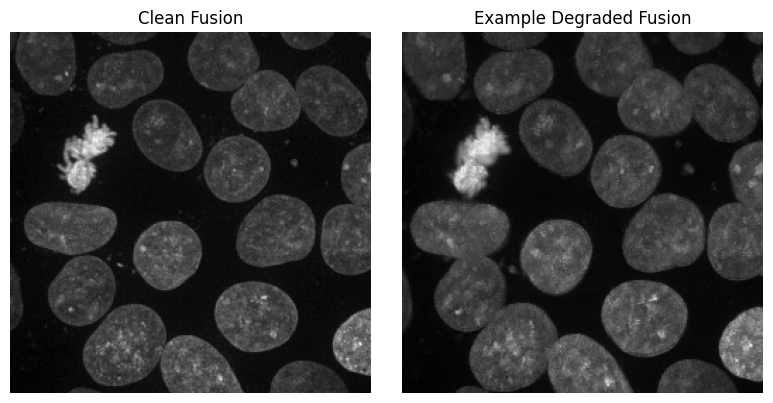

In [45]:
# @title 4.1 Generate multiple degraded stacks

# Create multiple degraded versions of the clean stack using different random seeds.
# These samples will be used to build the training dataset.
degraded_stacks = []
degraded_fusions = []

seeds = [1, 2, 3, 4, 5]
for seed in seeds:
    dstack = add_xy_z_drift(clean_stack, max_shift=6, max_sigma=2.0, seed=seed)
    degraded_stacks.append(dstack)
    degraded_fusions.append(mip_fusion(dstack))

# Show one example degraded fusion
example_degraded_fusion = degraded_fusions[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(clean_fusion, cmap="gray")
axes[0].set_title("Clean Fusion")
axes[0].axis("off")

axes[1].imshow(example_degraded_fusion, cmap="gray")
axes[1].set_title("Example Degraded Fusion")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [46]:
# @title 4.2 Build patch-based dataset

class FusionPatchDataset(Dataset):
    """
    Input:
        degraded z-stack patch with shape (Z, P, P)

    Target:
        clean fusion patch with shape (1, P, P)
    """
    def __init__(self, degraded_stacks, clean_fusion, patch_size=32, stride=8):
        self.inputs = []
        self.targets = []

        for degraded_stack in degraded_stacks:
            Z, H, W = degraded_stack.shape

            for y in range(0, H - patch_size + 1, stride):
                for x in range(0, W - patch_size + 1, stride):
                    inp = degraded_stack[:, y:y+patch_size, x:x+patch_size]
                    tgt = clean_fusion[y:y+patch_size, x:x+patch_size]

                    self.inputs.append(inp.astype(np.float32))
                    self.targets.append(tgt[None, ...].astype(np.float32))

        self.inputs = np.stack(self.inputs)
        self.targets = np.stack(self.targets)

        print("Dataset inputs shape:", self.inputs.shape)
        print("Dataset targets shape:", self.targets.shape)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.inputs[idx])
        y = torch.from_numpy(self.targets[idx])
        return x, y


dataset = FusionPatchDataset(
    degraded_stacks=degraded_stacks,
    clean_fusion=clean_fusion,
    patch_size=32,
    stride=8
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False)

Dataset inputs shape: (4205, 60, 32, 32)
Dataset targets shape: (4205, 1, 32, 32)


In [47]:
# @title 4.3 Define a small U-Net

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNetSmall(nn.Module):
    def __init__(self, in_channels, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(64, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.out_conv = nn.Sequential(
            nn.Conv2d(32, out_channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        u2 = torch.cat([u2, e2], dim=1)
        d2 = self.dec2(u2)

        u1 = self.up1(d2)
        u1 = torch.cat([u1, e1], dim=1)
        d1 = self.dec1(u1)

        out = self.out_conv(d1)
        return out


model = UNetSmall(in_channels=clean_stack.shape[0]).to(device)
print(model)

UNetSmall(
  (enc1): DoubleConv(
    (net): Sequential(
      (0): Conv2d(60, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (net): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): DoubleConv(
    (net): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
 

In [48]:
# @title 4.4 Define loss and optimizer

def laplacian_tensor(x):
    kernel = torch.tensor(
        [[0, 1, 0],
         [1, -4, 1],
         [0, 1, 0]],
        dtype=torch.float32,
        device=x.device
    ).view(1, 1, 3, 3)

    return F.conv2d(x, kernel, padding=1)


l1_loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 001/180 | Train Loss: 0.0949 | Val Loss: 0.0725
Epoch 010/180 | Train Loss: 0.0416 | Val Loss: 0.0416
Epoch 020/180 | Train Loss: 0.0333 | Val Loss: 0.0344
Epoch 030/180 | Train Loss: 0.0296 | Val Loss: 0.0324
Epoch 040/180 | Train Loss: 0.0274 | Val Loss: 0.0291
Epoch 050/180 | Train Loss: 0.0250 | Val Loss: 0.0278
Epoch 060/180 | Train Loss: 0.0240 | Val Loss: 0.0273
Epoch 070/180 | Train Loss: 0.0226 | Val Loss: 0.0262
Epoch 080/180 | Train Loss: 0.0219 | Val Loss: 0.0246
Epoch 090/180 | Train Loss: 0.0208 | Val Loss: 0.0240
Epoch 100/180 | Train Loss: 0.0203 | Val Loss: 0.0243
Epoch 110/180 | Train Loss: 0.0200 | Val Loss: 0.0237
Epoch 120/180 | Train Loss: 0.0193 | Val Loss: 0.0237
Epoch 130/180 | Train Loss: 0.0193 | Val Loss: 0.0230
Epoch 140/180 | Train Loss: 0.0188 | Val Loss: 0.0228
Epoch 150/180 | Train Loss: 0.0184 | Val Loss: 0.0222
Epoch 160/180 | Train Loss: 0.0179 | Val Loss: 0.0217
Epoch 170/180 | Train Loss: 0.0178 | Val Loss: 0.0215
Epoch 180/180 | Train Loss: 

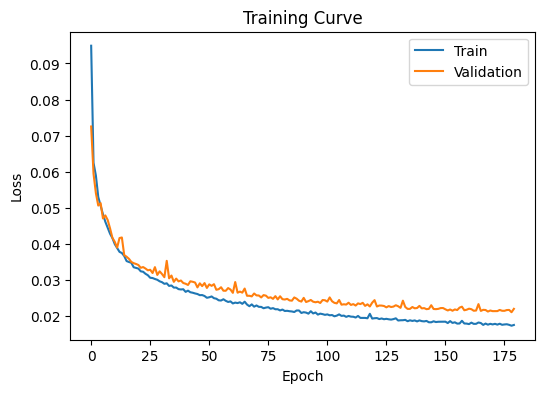

In [49]:
# @title 4.5 Train the model

num_epochs = 180
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        pred = model(xb)

        l1 = l1_loss_fn(pred, yb)
        edge = torch.mean(torch.abs(laplacian_tensor(pred) - laplacian_tensor(yb)))
        loss = l1 + 0.2 * edge

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train += loss.item() * xb.size(0)

    epoch_train = running_train / len(train_loader.dataset)
    train_losses.append(epoch_train)

    model.eval()
    running_val = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)

            l1 = l1_loss_fn(pred, yb)
            edge = torch.mean(torch.abs(laplacian_tensor(pred) - laplacian_tensor(yb)))
            loss = l1 + 0.2 * edge

            running_val += loss.item() * xb.size(0)

    epoch_val = running_val / len(val_loader.dataset)
    val_losses.append(epoch_val)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d}/{num_epochs} | Train Loss: {epoch_train:.4f} | Val Loss: {epoch_val:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.legend()
plt.show()

# 5. Reconstruction Results

In [50]:
# @title 5.1 Inference on one full degraded stack

test_degraded_stack = degraded_stacks[0]
test_degraded_fusion = degraded_fusions[0]

model.eval()
with torch.no_grad():
    x_full = torch.from_numpy(test_degraded_stack[None, ...].astype(np.float32)).to(device)
    pred_full = model(x_full).cpu().numpy()[0, 0]

pred_full = np.clip(pred_full, 0, 1)

In [51]:
# @title 5.2 Quantitative evaluation

def lap_var(img):
    return cv2.Laplacian(img.astype(np.float32), cv2.CV_32F).var()

ssim_degraded = ssim(clean_fusion, test_degraded_fusion, data_range=1.0)
ssim_reconstructed = ssim(clean_fusion, pred_full, data_range=1.0)

lap_clean = lap_var(clean_fusion)
lap_degraded = lap_var(test_degraded_fusion)
lap_reconstructed = lap_var(pred_full)

print(f"SSIM degraded vs clean: {ssim_degraded:.4f}")
print(f"SSIM reconstructed vs clean: {ssim_reconstructed:.4f}")
print(f"Laplacian variance (clean): {lap_clean:.6f}")
print(f"Laplacian variance (degraded): {lap_degraded:.6f}")
print(f"Laplacian variance (reconstructed): {lap_reconstructed:.6f}")

SSIM degraded vs clean: 0.5002
SSIM reconstructed vs clean: 0.9458
Laplacian variance (clean): 0.009879
Laplacian variance (degraded): 0.008055
Laplacian variance (reconstructed): 0.007986


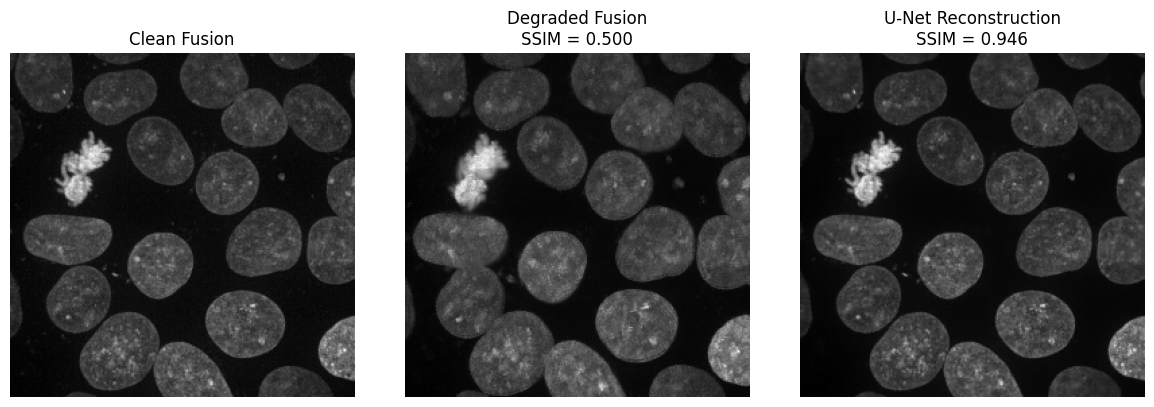

In [52]:
# @title 5.3 Final visualization

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(clean_fusion, cmap="gray")
axes[0].set_title("Clean Fusion")
axes[0].axis("off")

axes[1].imshow(test_degraded_fusion, cmap="gray")
axes[1].set_title(f"Degraded Fusion\nSSIM = {ssim_degraded:.3f}")
axes[1].axis("off")

axes[2].imshow(pred_full, cmap="gray")
axes[2].set_title(f"U-Net Reconstruction\nSSIM = {ssim_reconstructed:.3f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

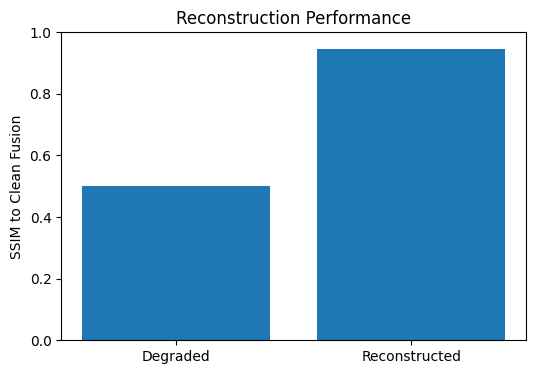

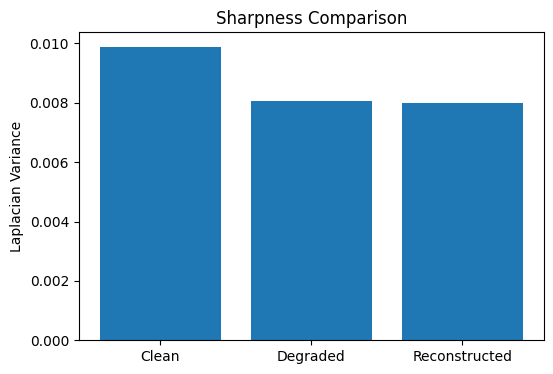

In [53]:
# @title 5.4 Metric bar charts

plt.figure(figsize=(6, 4))
plt.bar(["Degraded", "Reconstructed"], [ssim_degraded, ssim_reconstructed])
plt.ylim(0, 1.0)
plt.ylabel("SSIM to Clean Fusion")
plt.title("Reconstruction Performance")
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(
    ["Clean", "Degraded", "Reconstructed"],
    [lap_clean, lap_degraded, lap_reconstructed]
)
plt.ylabel("Laplacian Variance")
plt.title("Sharpness Comparison")
plt.show()